# Combine NS+OPS and extra_data

This example illustrates how to:

- Load data from two different instruments (NS and OPS)
- Combine them on a common time base
- Inspect and use the `extra_data` tables

In [ ]:
import matplotlib.pyplot as plt
import aerosoltools as at

## Load NS and OPS datasets

A sample NanoScan (NS) and several OPS files are included in the test data directory. Here we utilize the very efficient `Load_data_from_folder` function, which can load and combine multiple files from the same instrument, by specifying a path and the loader function to use. In this example we also specify a (optional) search_word, which can be used to load only files containing this specific keyword in their name.

In [5]:
ns_file = r"..\..\tests\data\Combine_example_NS.csv"
ops_path = r"..\..\tests\data"

ns = at.Load_NS_file(ns_file, extra_data  =True)
ops = at.Load_data_from_folder(ops_path, at.Load_OPS_file, search_word="Combine_example",extra_data=True)

Loading files:   0%|          | 0/5 [00:00<?, ?file/s]


File load summary:

+----------------------------------+---------+------------------------------------------------------------------------------------+
|               File               | Status  |                                       Reason                                       |
+----------------------------------+---------+------------------------------------------------------------------------------------+
| Combine_example_OPS - file 1.csv | Loaded  |                                         -                                          |
| Combine_example_OPS - file 2.csv | Loaded  |                                         -                                          |
| Combine_example_OPS - file 3.csv | Loaded  |                                         -                                          |
| Combine_example_OPS - file 4.csv | Loaded  |                                         -                                          |
|      Combine_example_NS.csv      | Skipped | IndexErr

The `Load_data_from_folder` function displays a progress bar so you can see how many files are loaded and the progress. In addition it prints a summary table, listing the files that were loaded, those that were skipped, and a reason as to why these were skipped. 

This enables you to load many files from a folder, which can include from subfolders, even if the folder contains many different files, where a simple search_word cannot distinguish them efficiently.

## Inspect `extra_data` for each instrument

Many loaders store auxiliary variables (e.g. flow, temperature, status flags)
in the `.extra_data` attribute.

In [6]:
print("NS extra-data columns:", list(ns.extra_data.columns))
print("OPS extra-data columns:", list(ops.extra_data.columns))

# Show a small snippet if available
display(ns.extra_data.head())
display(ops.extra_data.head())

NS extra-data columns: ['Median (nm)', 'Mean (nm)', 'Geo Mean (nm)', 'Mode (nm)', 'GSD', 'Particle Density (g/cc)', 'Firmware Version', 'Status']
OPS extra-data columns: ['Bin 1', 'Deadtime (s)', 'Temperature (C)', 'Humidity (%)', 'Ambient Pressure (kPa)', 'Alarms', 'Errors', 'Unnamed: 24']


,Median (nm),Mean (nm),Geo Mean (nm),Mode (nm),GSD,Particle Density (g/cc),Firmware Version,Status
Datetime,,,,,,,,
2023-05-30 15:41:29,15.7036,25.3091,18.5497,15.3993,1.8865,1.0,1.4,Filling reservoir;
2023-05-30 15:42:29,16.7808,29.9378,21.1565,15.3993,2.0303,1.0,1.4,No errors
2023-05-30 15:43:29,15.6058,21.0331,17.1038,15.3993,1.6626,1.0,1.4,Filling reservoir;
2023-05-30 15:44:29,15.7465,21.2670,17.2874,15.3993,1.6668,1.0,1.4,No errors
2023-05-30 15:45:29,16.3273,24.3266,18.8023,15.3993,1.7967,1.0,1.4,No errors


,Bin 1,Deadtime (s),Temperature (C),Humidity (%),Ambient Pressure (kPa),Alarms,Errors,Unnamed: 24
Datetime,,,,,,,,
2023-10-23 13:30:44,0,0.000000,30.668,0.0,100.739,NaN,NaN,NaN
2023-10-23 13:31:44,144,0.007004,30.724,0.0,100.733,NaN,NaN,NaN
2023-10-23 13:32:44,2186,0.103820,30.804,0.0,100.732,NaN,NaN,NaN
2023-10-23 13:33:44,0,0.000000,30.867,0.0,100.733,NaN,NaN,NaN
2023-10-23 13:34:44,0,0.000000,30.932,0.0,100.729,NaN,NaN,NaN


## Combine NS and OPS on a common time grid

The helper function `Combine_NS_OPS` aligns the two instruments in time and returns a combined dataset suitable for correlation analysis. If the timestamps between the two datasets does not match precisely e.g. differ a few seconds, then the matching can be relaxed via the `match` keyword. This can be set to either nearest, matching nearest datapoint within a tolerance time window. 

If the two datasets do not have the same sampling frequency e.g. one is per minute and the other is every second, the function can be called with `match = "rebin", rebin_freq = "1min"`, in which case the high frequency data is rebinned into 1 min times to match the low frequency data. A larger and common frequency can also be set.

In [11]:
combined = at.Combine_NS_OPS(ns, ops, match="nearest",tolerance="30s",)
combined.data

,Total_conc,11.5,15.4,20.5,27.4,36.5,48.7,64.9,86.6,115.5,...,1561.5,1944.0,2420.5,3014.0,3752.5,4672.0,5816.5,7241.0,9015.5,All data
Datetime,,,,,,,,,,,,,,,,,,,,,
2023-10-23 13:31:19,28754.398451,1485.4313,3835.8508,4568.8809,5940.7231,5474.6567,3735.8103,1953.4159,1017.3690,560.3550,...,0.052996,0.035997,0.026998,0.024998,0.013999,0.006000,0.006000,0.002000,0.004000,True
2023-10-23 13:32:19,28443.038346,1638.4261,3983.9104,4449.2646,5711.5151,5321.5229,3699.7014,1971.2294,1002.8712,513.6530,...,0.547839,0.462708,0.430659,0.332509,0.221339,0.110169,0.081124,0.055084,0.055084,True
2023-10-23 13:33:19,28263.426000,1432.7457,3766.0723,4466.9683,5829.9810,5441.0298,3779.6973,2001.2233,994.9397,468.5747,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,True
2023-10-23 13:34:19,27502.510700,1694.3612,3835.4392,4182.8892,5507.8789,5217.7969,3656.2771,1933.9193,948.3063,440.3977,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,True
2023-10-23 13:35:19,28912.922700,1746.8145,3937.4988,4386.7480,5792.1016,5432.0537,3771.3831,2020.9584,1083.6498,585.2220,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-10-26 23:22:58,10894.390593,566.0240,1299.7166,1351.1873,2046.0566,2273.6438,1849.0562,1053.4200,357.7328,0.0000,...,2.181798,1.857042,1.711253,1.462910,0.872719,0.421278,0.319729,0.257392,0.282528,True
2023-10-26 23:23:58,10677.534091,521.8893,1213.6832,1371.0192,1979.4780,2195.3396,1825.7404,1096.6410,402.9259,0.0000,...,1.891105,1.637886,1.498213,1.254038,0.832006,0.356717,0.293413,0.204987,0.275326,True
2023-10-26 23:24:58,10860.292970,610.1611,1343.8060,1359.7363,2005.8888,2241.7649,1834.1871,1037.4493,314.7814,0.0000,...,4.024242,3.527272,3.099999,2.460606,1.529293,0.713131,0.507071,0.369697,0.429293,True


The resulting variable is an aerosol2d class object, with the same functionalities as the raw loaded data. It is thus possible to plot particle data in the broad size range from 10 nm (Nanoscan lower limit) to 10 µm (OPS upper limit).

The two datasets are combined by simply discarding the upper bins of the Nanoscan, while including all of the OPS bins, as the nanoscan is known to be uncertain at upper range of its particle size spectrum.

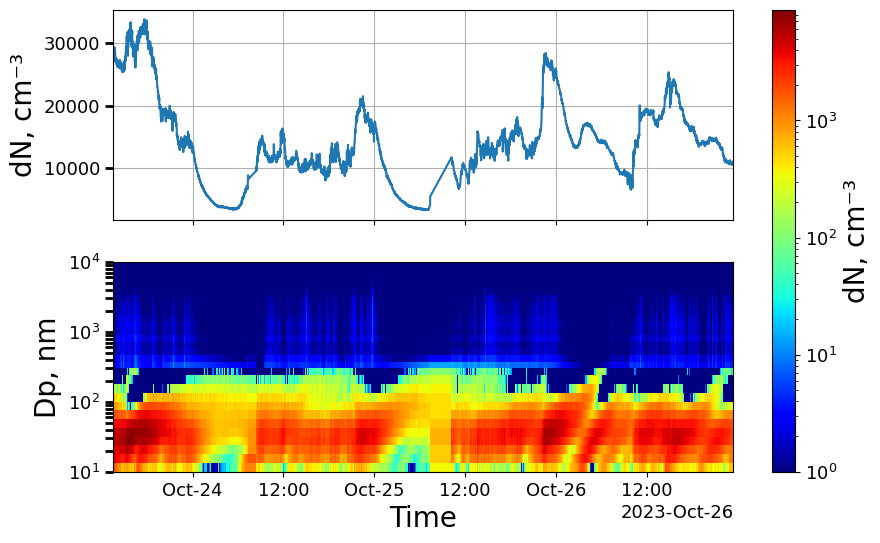

In [16]:
combined.plot_timeseries(y_3d=(1,0));
# as some bins have concentrations of 0 cm-3 it is necessary to set the lower limit to 1 via y_3d = (1,0)
# the upper limit of 0 indicates that the maximum value in the data should be used. 